In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Raw/Image_Data"

print("Image path exists:", os.path.exists(IMAGE_PATH))

Image path exists: True


In [ ]:
for root, dirs, files in os.walk(IMAGE_PATH):
    level = root.replace(IMAGE_PATH, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}    {file}")

Image_Data/
    Orignal-Dataset/
        Yellow_Soil/
            4.jpg
            2.jpg
            1.jpg
            41e.jpg
            33.jpg
        Arid_Soil/
            1.jpg
            10.jpg
            100.jpg
            101.jpg
            103.jpg
        Red_Soil/
            29.jpg
            42.jpg
            54a.jpg
            41.jpg
            25.jpg
        Mountain_Soil/
            107b.jpg
            176.jpg
            131.jpg
            112.jpg
            116a.jpg
        Laterite_Soil/
            21.jpg
            127.jpg
            143.jpg
            109.jpg
            153.jpg
        Alluvial_Soil/
            1.jpg
            10.jpg
            100.jpg
            101.jpg
            103.jpg
        Black_Soil/
            130.jpg
            116.jpg
            110.jpg
            176a.jpg
            103.jpg


In [ ]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

image_files = []

for root, dirs, files in os.walk(IMAGE_PATH):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print("Total images:", len(image_files))

Total images: 1188


In [ ]:
sample_images = image_files[:9]

plt.figure(figsize=(12, 10))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
IMAGE_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Raw/Image_Data/Orignal-Dataset"

image_extensions = (".jpg", ".jpeg", ".png")

class_counts = {}

for class_name in os.listdir(IMAGE_PATH):
    class_path = os.path.join(IMAGE_PATH, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        ])

        class_counts[class_name] = image_count

print("=" * 60)
print("IMAGE DATASET SUMMARY")
print("=" * 60)

print("\nNumber of classes:", len(class_counts))
print("\nImages per class:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal images:", sum(class_counts.values()))

IMAGE DATASET SUMMARY

Number of classes: 7

Images per class:
Yellow_Soil: 69
Arid_Soil: 284
Red_Soil: 109
Mountain_Soil: 201
Laterite_Soil: 219
Alluvial_Soil: 51
Black_Soil: 255

Total images: 1188


In [ ]:
image_info = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            image_info.append({
                "filename": os.path.basename(img_path),
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })
    except Exception as e:
        pass

image_df = pd.DataFrame(image_info)

print("Image dataset shape:", image_df.shape)

display(image_df.head())

Image dataset shape: (1188, 4)


,filename,width,height,mode
0,4.jpg,645,407,RGB
1,2.jpg,1600,1045,RGB
2,1.jpg,753,1000,RGB
3,41e.jpg,372,336,RGB
4,33.jpg,474,299,RGB


In [ ]:
print("=" * 60)
print("IMAGE DIMENSION STATISTICS")
print("=" * 60)

display(image_df[["width", "height"]].describe())

IMAGE DIMENSION STATISTICS


,width,height
count,1188.000000,1188.000000
mean,734.691919,506.091751
std,484.468441,327.285477
min,140.000000,101.000000
25%,405.000000,271.750000
50%,608.000000,408.000000
75%,928.250000,636.000000
max,3888.000000,2592.000000


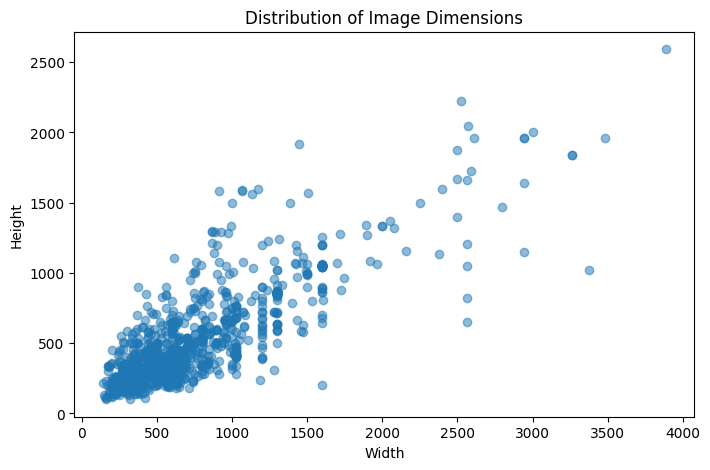

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(image_df["width"], image_df["height"], alpha=0.5)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribution of Image Dimensions")

plt.show()

In [ ]:
print("=" * 60)
print("IMAGE COLOR MODES")
print("=" * 60)

print(image_df["mode"].value_counts())

IMAGE COLOR MODES
mode
RGB    1188
Name: count, dtype: int64


In [ ]:
corrupted_images = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        corrupted_images.append(img_path)

print("Total images:", len(image_files))
print("Corrupted images:", len(corrupted_images))

Total images: 1188
Corrupted images: 0


In [ ]:
import hashlib
from collections import defaultdict

def get_image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

image_hashes = defaultdict(list)

for img_path in image_files:
    try:
        img_hash = get_image_hash(img_path)
        image_hashes[img_hash].append(img_path)
    except Exception:
        pass

duplicate_groups = {
    img_hash: paths
    for img_hash, paths in image_hashes.items()
    if len(paths) > 1
}

duplicate_count = sum(
    len(paths) - 1
    for paths in duplicate_groups.values()
)

print("=" * 60)
print("DUPLICATE IMAGE CHECK")
print("=" * 60)

print("Total images:", len(image_files))
print("Duplicate image groups:", len(duplicate_groups))
print("Additional duplicate images:", duplicate_count)

if duplicate_groups:
    print("\nExample duplicate group:")
    first_group = next(iter(duplicate_groups.values()))
    for path in first_group:
        print(path)
else:
    print("\nNo duplicate images found.")

DUPLICATE IMAGE CHECK
Total images: 1188
Duplicate image groups: 48
Additional duplicate images: 49

Example duplicate group:
/content/drive/MyDrive/Soil_Analytics_Project/Data/Raw/Image_Data/Orignal-Dataset/Yellow_Soil/16.jpg
/content/drive/MyDrive/Soil_Analytics_Project/Data/Raw/Image_Data/Orignal-Dataset/Yellow_Soil/53.jpg


In [ ]:
import os

removed_files = []

for img_hash, paths in duplicate_groups.items():
    # Keep the first image, remove the rest
    for duplicate_path in paths[1:]:
        try:
            os.remove(duplicate_path)
            removed_files.append(duplicate_path)
        except Exception as e:
            print(f"Could not remove {duplicate_path}: {e}")

print("=" * 60)
print("DUPLICATE REMOVAL COMPLETE")
print("=" * 60)
print(f"Images removed: {len(removed_files)}")
print(f"Images remaining: {len(image_files) - len(removed_files)}")

DUPLICATE REMOVAL COMPLETE
Images removed: 49
Images remaining: 1139


In [ ]:
from collections import Counter
import os
import glob

# Re-scan all images after duplicate removal
image_extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")

image_files_clean = []

for ext in image_extensions:
    image_files_clean.extend(
        glob.glob(os.path.join(IMAGE_PATH, "**", ext), recursive=True)
    )

# Get class names from parent folders
class_names_clean = [
    os.path.basename(os.path.dirname(img_path))
    for img_path in image_files_clean
]

class_counts_clean = Counter(class_names_clean)

print("=" * 60)
print("FINAL CLEANED DATASET")
print("=" * 60)

print(f"\nTotal images: {len(image_files_clean)}")
print(f"Number of classes: {len(class_counts_clean)}")

print("\nImages per soil class:")
for class_name, count in sorted(class_counts_clean.items()):
    print(f"{class_name}: {count}")

FINAL CLEANED DATASET

Total images: 1139
Number of classes: 7

Images per soil class:
Alluvial_Soil: 49
Arid_Soil: 279
Black_Soil: 234
Laterite_Soil: 214
Mountain_Soil: 191
Red_Soil: 107
Yellow_Soil: 65


In [ ]:
valid_classes = {
    "Alluvial_Soil",
    "Arid_Soil",
    "Black_Soil",
    "Laterite_Soil",
    "Mountain_Soil",
    "Red_Soil",
    "Yellow_Soil"
}

invalid_labels = []
verified_images = 0

for img_path in image_files_clean:
    label = os.path.basename(os.path.dirname(img_path))

    if label in valid_classes:
        verified_images += 1
    else:
        invalid_labels.append((img_path, label))

print("=" * 60)
print("IMAGE LABEL VERIFICATION")
print("=" * 60)

print(f"\nValid soil classes: {len(valid_classes)}")
print(f"Images with valid labels: {verified_images}")
print(f"Images with invalid labels: {len(invalid_labels)}")

print("\nClass labels:")
for label in sorted(valid_classes):
    print(f"✓ {label}")

if invalid_labels:
    print("\nInvalid label examples:")
    for item in invalid_labels[:10]:
        print(item)
else:
    print("\n✓ All image labels are valid!")

IMAGE LABEL VERIFICATION

Valid soil classes: 7
Images with valid labels: 1139
Images with invalid labels: 0

Class labels:
✓ Alluvial_Soil
✓ Arid_Soil
✓ Black_Soil
✓ Laterite_Soil
✓ Mountain_Soil
✓ Red_Soil
✓ Yellow_Soil

✓ All image labels are valid!


In [ ]:
from PIL import Image
import os

# Paths
PROCESSED_IMAGE_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Data"

# Target image size
TARGET_SIZE = (224, 224)

# Create output folder
os.makedirs(PROCESSED_IMAGE_PATH, exist_ok=True)

resized_count = 0
failed_count = 0

for img_path in image_files_clean:

    # Get the soil class name
    class_name = os.path.basename(os.path.dirname(img_path))

    # Create class folder in Processed directory
    output_class_path = os.path.join(PROCESSED_IMAGE_PATH, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    # Output image path
    filename = os.path.basename(img_path)
    output_path = os.path.join(output_class_path, filename)

    try:
        with Image.open(img_path) as img:

            # Convert to RGB
            img = img.convert("RGB")

            # Resize
            img = img.resize(TARGET_SIZE)

            # Save processed image
            img.save(output_path)

            resized_count += 1

    except Exception as e:
        failed_count += 1
        print(f"Failed: {img_path}")

print("=" * 60)
print("IMAGE RESIZING COMPLETE")
print("=" * 60)
print(f"Target size: {TARGET_SIZE}")
print(f"Images resized: {resized_count}")
print(f"Failed images: {failed_count}")
print(f"Saved to: {PROCESSED_IMAGE_PATH}")

IMAGE RESIZING COMPLETE
Target size: (224, 224)
Images resized: 1139
Failed images: 0
Saved to: /content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Data


In [ ]:
from PIL import Image
import glob
import os
from collections import Counter

processed_files = glob.glob(
    os.path.join(PROCESSED_IMAGE_PATH, "**", "*.*"),
    recursive=True
)

# Keep only image files
processed_files = [
    f for f in processed_files
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sizes = Counter()
invalid_size_images = []

for img_path in processed_files:
    try:
        with Image.open(img_path) as img:
            sizes[img.size] += 1

            if img.size != TARGET_SIZE:
                invalid_size_images.append(img_path)
    except Exception:
        invalid_size_images.append(img_path)

print("=" * 60)
print("RESIZED IMAGE VERIFICATION")
print("=" * 60)

print(f"\nTotal processed images: {len(processed_files)}")
print(f"Expected size: {TARGET_SIZE}")
print(f"Images with correct size: {len(processed_files) - len(invalid_size_images)}")
print(f"Images with incorrect size: {len(invalid_size_images)}")

print("\nImage size distribution:")
for size, count in sizes.items():
    print(f"{size}: {count}")

RESIZED IMAGE VERIFICATION

Total processed images: 1139
Expected size: (224, 224)
Images with correct size: 1139
Images with incorrect size: 0

Image size distribution:
(224, 224): 1139


In [ ]:
import numpy as np
from PIL import Image

# Select one processed image
sample_image_path = processed_files[0]

# Load image
img = Image.open(sample_image_path).convert("RGB")

# Convert image to NumPy array
img_array = np.array(img)

print("=" * 60)
print("IMAGE NORMALIZATION")
print("=" * 60)

print("\nBefore normalization:")
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())
print("Data type:", img_array.dtype)

# Normalize pixel values from 0–255 to 0–1
normalized_image = img_array / 255.0

print("\nAfter normalization:")
print("Minimum pixel value:", normalized_image.min())
print("Maximum pixel value:", normalized_image.max())
print("Data type:", normalized_image.dtype)

print("\n✓ Image normalization successful!")

IMAGE NORMALIZATION

Before normalization:
Minimum pixel value: 0
Maximum pixel value: 255
Data type: uint8

After normalization:
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Data type: float64

✓ Image normalization successful!


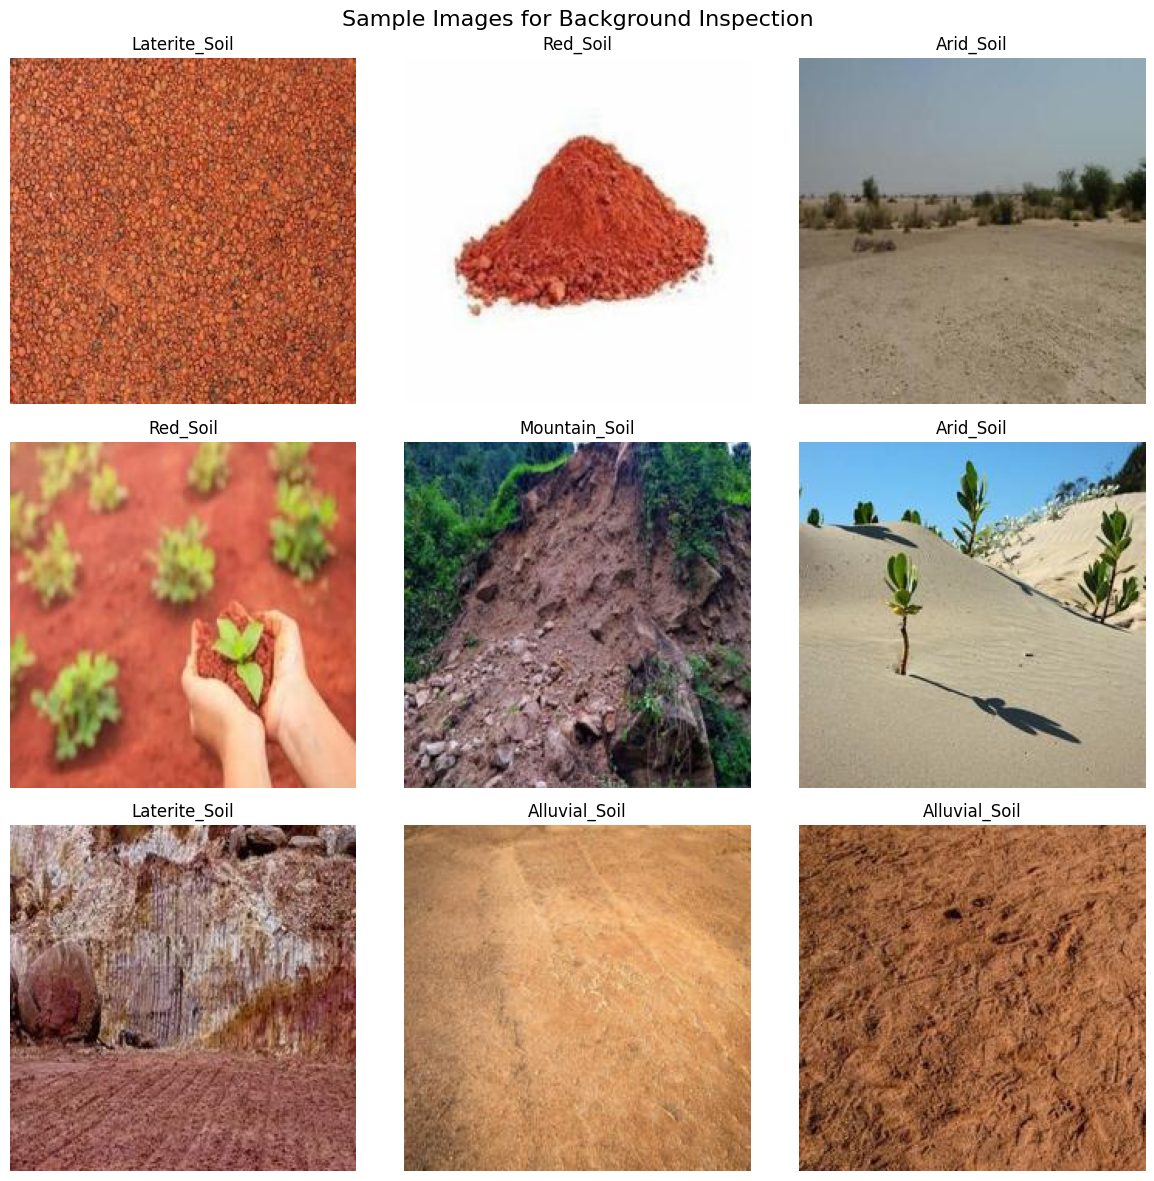

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Select random sample images
sample_paths = random.sample(processed_files, 9)

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(sample_paths):
    img = Image.open(img_path).convert("RGB")
    class_name = os.path.basename(os.path.dirname(img_path))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample Images for Background Inspection", fontsize=16)
plt.tight_layout()
plt.show()

IMAGE CLASS DISTRIBUTION
Alluvial_Soil: 49
Arid_Soil: 279
Black_Soil: 234
Laterite_Soil: 214
Mountain_Soil: 191
Red_Soil: 107
Yellow_Soil: 65

Total images: 1139
Number of classes: 7


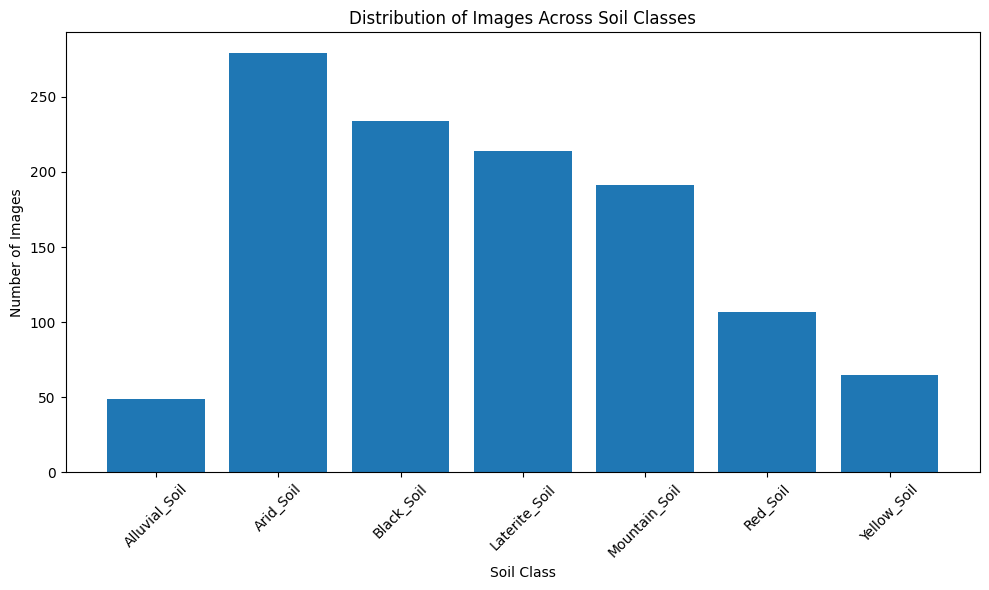

In [ ]:
import os
import matplotlib.pyplot as plt

# Path to processed image dataset
PROCESSED_IMAGE_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Data"

# Get class names and count images in each class
class_names = []
image_counts = []

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

for class_name in sorted(os.listdir(PROCESSED_IMAGE_PATH)):
    class_path = os.path.join(PROCESSED_IMAGE_PATH, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(image_extensions)
        ])

        class_names.append(class_name)
        image_counts.append(count)

# Print distribution
print("=" * 60)
print("IMAGE CLASS DISTRIBUTION")
print("=" * 60)

for class_name, count in zip(class_names, image_counts):
    print(f"{class_name}: {count}")

print(f"\nTotal images: {sum(image_counts)}")
print(f"Number of classes: {len(class_names)}")

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(class_names, image_counts)

plt.title("Distribution of Images Across Soil Classes")
plt.xlabel("Soil Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
print("=" * 70)
print("IMAGE DATA EDA SUMMARY")
print("=" * 70)

print("""
1. The image dataset contains 1,139 images across 7 soil classes.

2. Duplicate image analysis identified duplicate images, which were removed
   during data cleaning.

3. All remaining images have valid class labels.

4. Images were successfully resized to a standard size of 224 × 224 pixels.

5. Image normalization was completed successfully, converting pixel values
   from the range 0–255 to the range 0–1.

6. Visual inspection showed variation in image backgrounds, lighting,
   textures, and soil appearances.

7. The dataset has an imbalanced class distribution:
   - Arid_Soil has the highest number of images.
   - Alluvial_Soil has the lowest number of images.

8. Class imbalance should be considered during the model development stage,
   potentially using techniques such as data augmentation or class weighting.
""")

print("=" * 70)
print("IMAGE DATA EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

IMAGE DATA EDA SUMMARY

1. The image dataset contains 1,139 images across 7 soil classes.

2. Duplicate image analysis identified duplicate images, which were removed
   during data cleaning.

3. All remaining images have valid class labels.

4. Images were successfully resized to a standard size of 224 × 224 pixels.

5. Image normalization was completed successfully, converting pixel values
   from the range 0–255 to the range 0–1.

6. Visual inspection showed variation in image backgrounds, lighting,
   textures, and soil appearances.

7. The dataset has an imbalanced class distribution:
   - Arid_Soil has the highest number of images.
   - Alluvial_Soil has the lowest number of images.

8. Class imbalance should be considered during the model development stage,
   potentially using techniques such as data augmentation or class weighting.

IMAGE DATA EDA COMPLETED SUCCESSFULLY


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("=" * 60)
print("IMAGE AUGMENTATION SETUP")
print("=" * 60)

# Define augmentation techniques
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("✓ Image augmentation configuration created successfully!")

print("\nAugmentation techniques:")
print("✓ Rotation")
print("✓ Width shifting")
print("✓ Height shifting")
print("✓ Shearing")
print("✓ Zooming")
print("✓ Horizontal flipping")

IMAGE AUGMENTATION SETUP
✓ Image augmentation configuration created successfully!

Augmentation techniques:
✓ Rotation
✓ Width shifting
✓ Height shifting
✓ Shearing
✓ Zooming
✓ Horizontal flipping


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Select one sample image
sample_image_path = image_files[0]

# Load image
img = load_img(sample_image_path, target_size=(224, 224))
img_array = img_to_array(img)

# Add batch dimension
img_array = img_array.reshape((1,) + img_array.shape)

# Generate augmented images
plt.figure(figsize=(15, 8))

for i, batch in enumerate(datagen.flow(img_array, batch_size=1)):

    plt.subplot(2, 4, i + 1)
    plt.imshow(batch[0].astype('uint8'))
    plt.axis('off')
    plt.title(f"Augmented {i+1}")

    if i == 7:
        break

plt.suptitle("Image Augmentation Examples", fontsize=16)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os
import shutil
import random
from pathlib import Path



SOURCE_DIR = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Data"

OUTPUT_DIR = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Split"


TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


random.seed(42)


for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)


classes = [
    folder for folder in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, folder))
]

print("=" * 60)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 60)


for soil_class in classes:

    class_path = os.path.join(SOURCE_DIR, soil_class)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]


    random.shuffle(images)

    total = len(images)


    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]


    split_data = {
        "train": train_images,
        "validation": val_images,
        "test": test_images
    }

    for split, image_list in split_data.items():

        destination = os.path.join(OUTPUT_DIR, split, soil_class)
        os.makedirs(destination, exist_ok=True)

        for image_name in image_list:
            source_file = os.path.join(class_path, image_name)
            destination_file = os.path.join(destination, image_name)

            shutil.copy2(source_file, destination_file)

    print(f"\n{soil_class}")
    print(f"  Total:      {total}")
    print(f"  Train:      {len(train_images)}")
    print(f"  Validation: {len(val_images)}")
    print(f"  Test:       {len(test_images)}")

print("\n" + "=" * 60)
print("✓ DATA SPLIT COMPLETED SUCCESSFULLY")
print("=" * 60)

TRAIN / VALIDATION / TEST SPLIT

Yellow_Soil
  Total:      65
  Train:      45
  Validation: 9
  Test:       11

Arid_Soil
  Total:      279
  Train:      195
  Validation: 41
  Test:       43

Red_Soil
  Total:      107
  Train:      74
  Validation: 16
  Test:       17

Mountain_Soil
  Total:      191
  Train:      133
  Validation: 28
  Test:       30

Laterite_Soil
  Total:      214
  Train:      149
  Validation: 32
  Test:       33

Alluvial_Soil
  Total:      49
  Train:      34
  Validation: 7
  Test:       8

Black_Soil
  Total:      234
  Train:      163
  Validation: 35
  Test:       36

✓ DATA SPLIT COMPLETED SUCCESSFULLY


In [ ]:
import os

print("=" * 60)
print("TRAIN / VALIDATION / TEST SPLIT VERIFICATION")
print("=" * 60)

grand_total = 0

for split in ["train", "validation", "test"]:

    split_path = os.path.join(OUTPUT_DIR, split)
    split_total = 0

    print(f"\n{split.upper()} SET")
    print("-" * 40)

    for soil_class in sorted(os.listdir(split_path)):

        class_path = os.path.join(split_path, soil_class)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

            split_total += count
            print(f"{soil_class}: {count}")

    print(f"\nTotal {split} images: {split_total}")
    grand_total += split_total

print("\n" + "=" * 60)
print(f"TOTAL IMAGES ACROSS ALL SPLITS: {grand_total}")
print("=" * 60)

if grand_total == 1139:
    print("✓ VERIFICATION SUCCESSFUL — All images accounted for!")
else:
    print("⚠ Image count mismatch — please check the split.")

TRAIN / VALIDATION / TEST SPLIT VERIFICATION

TRAIN SET
----------------------------------------
Alluvial_Soil: 34
Arid_Soil: 195
Black_Soil: 163
Laterite_Soil: 149
Mountain_Soil: 133
Red_Soil: 74
Yellow_Soil: 45

Total train images: 793

VALIDATION SET
----------------------------------------
Alluvial_Soil: 7
Arid_Soil: 41
Black_Soil: 35
Laterite_Soil: 32
Mountain_Soil: 28
Red_Soil: 16
Yellow_Soil: 9

Total validation images: 168

TEST SET
----------------------------------------
Alluvial_Soil: 8
Arid_Soil: 43
Black_Soil: 36
Laterite_Soil: 33
Mountain_Soil: 30
Red_Soil: 17
Yellow_Soil: 11

Total test images: 178

TOTAL IMAGES ACROSS ALL SPLITS: 1139
✓ VERIFICATION SUCCESSFUL — All images accounted for!
